In [1]:
XENIUM_DATA_DIR = '/global/scratch/users/fosterangus/MetabTravLR/Data/Xenium'
DATASET_NAME = 'FFPE_Human_Ovarian_Cancer'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 407124 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_res_0.05', 'leiden_scVI_res_0.05_colors', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.1_colors', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.25_colors', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.375_colors', 'leiden_scVI_res_0.5', 'leiden_scVI_res_0.5_colors', 'leiden_scVI_res_0.

/tmp/ipykernel_2492726/12019399.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');


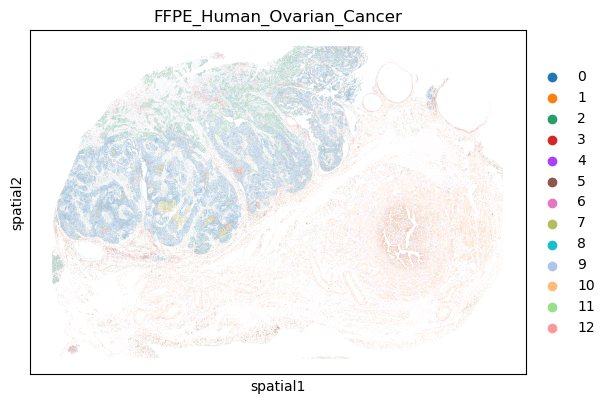

In [4]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');

In [5]:
# Make sure counts layer exists
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

# Build log_norm layer from counts if it doesn't exist
if 'log_norm' not in adata.layers:
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers['log_norm'] = adata.X.copy()
    # Restore raw counts to X
    adata.X = adata.layers['counts'].copy()

print("Layers available:", list(adata.layers.keys()))
print("X max (should be large if raw counts):", adata.X.max())
print("log_norm max (should be small, ~log scale):", adata.layers['log_norm'].max())

/tmp/ipykernel_2492726/1663927226.py:8: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, target_sum=1e4)


Layers available: ['counts', 'log_norm']
X max (should be large if raw counts): 177.0
log_norm max (should be small, ~log scale): 9.210441


In [6]:
# resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5, 0.375, 0.25, 0.1, 0.05]
resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5]
def res_label(res):
    return f'leiden_scVI_res_{res}'
res_labels = [res_label(res) for res in resolutions]

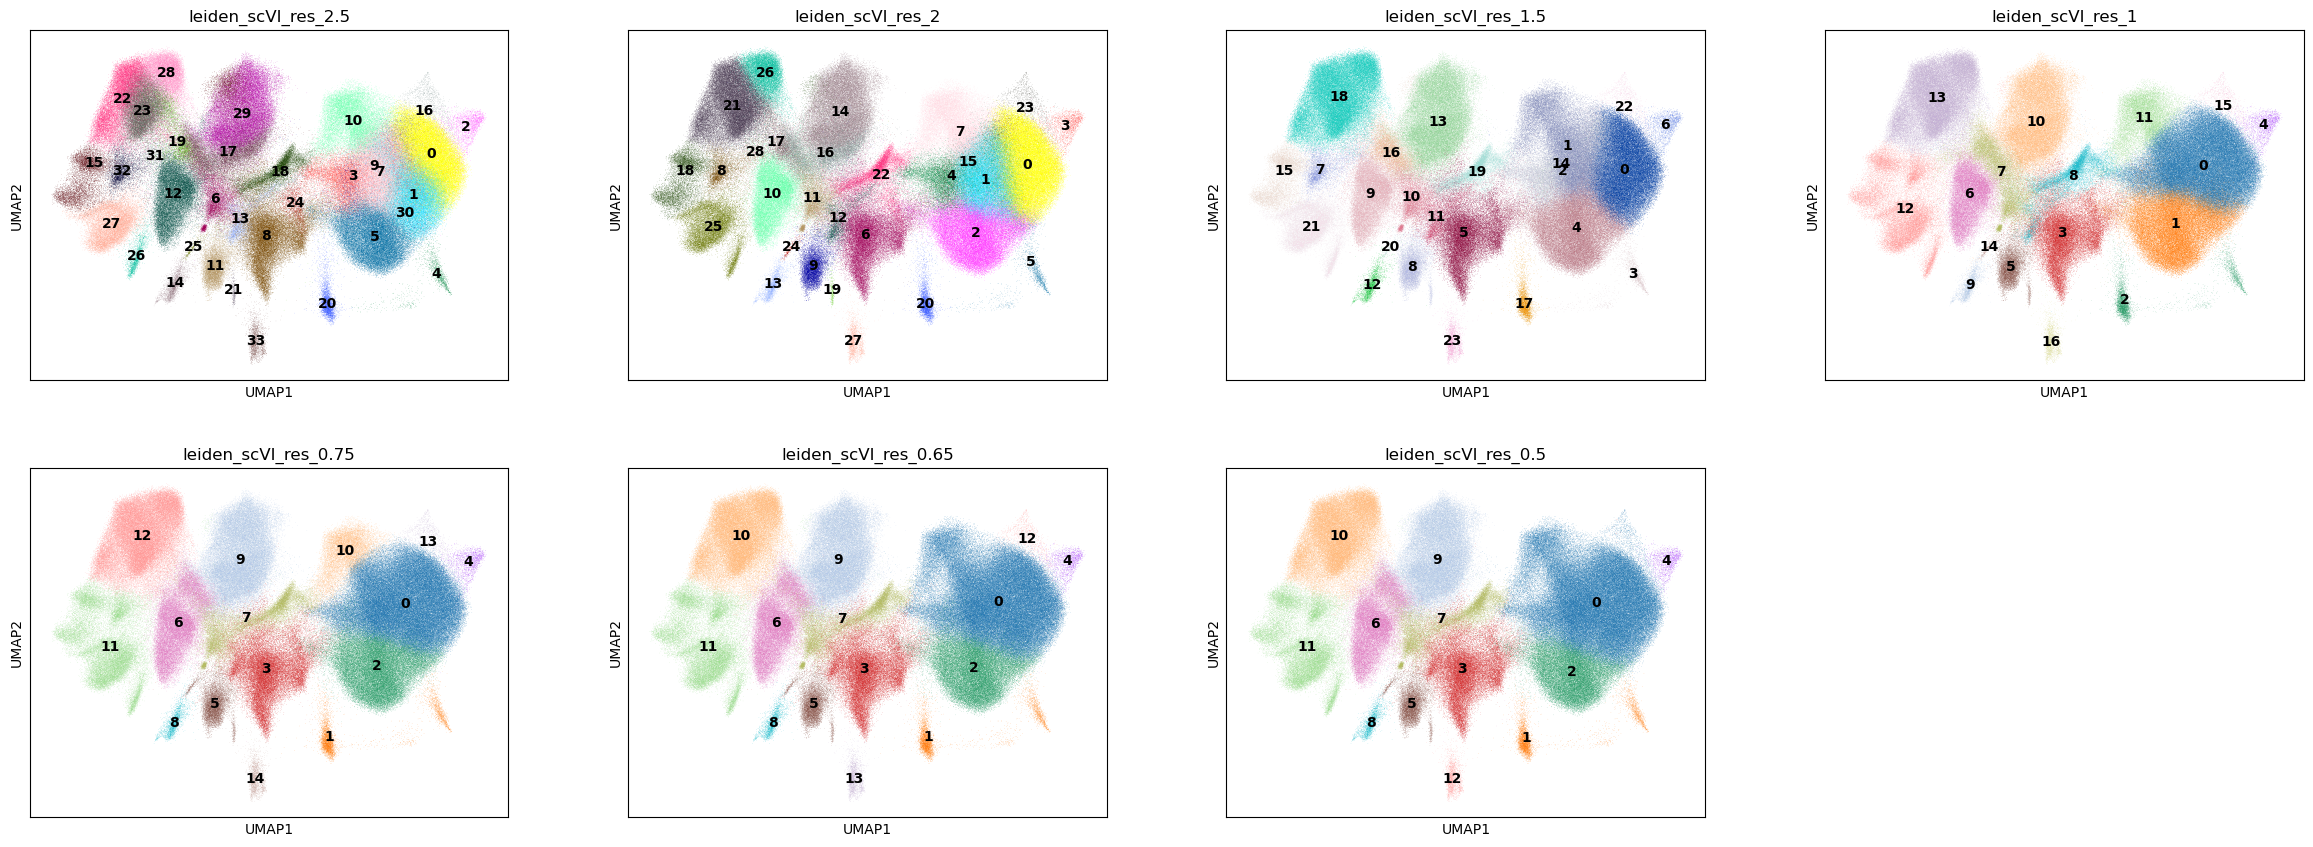

In [7]:
sc.pl.umap(adata, color=res_labels, legend_loc="on data")


RESOLUTION: leiden_scVI_res_2.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['UCHL1', 'CD47', 'SMC4', 'HNRNPD', 'LAPTM4B', 'H19', 'TPX2', 'BIRC5', 'HMGA1', 'HSPD1', 'TOP2A', 'PTGES3', 'PRKCI', 'MYBL2', 'EPCAM']
Cluster 1: ['LAPTM4B', 'PLXNB1', 'EEF1G', 'CD47', 'ESR1', 'PVT1', 'CYP4B1', 'PRKCI', 'HNRNPD', 'AHCY', 'NORAD', 'HNRNPA1L2', 'FBL', 'HSPD1', 'CP']
Cluster 2: ['HSPD1', 'SMC4', 'HSPE1', 'PRKCI', 'BIRC5', 'HNRNPD', 'KPNA2', 'TOP2A', 'CCNB1', 'PTGES3', 'CTNNB1', 'CD47', 'CSE1L', 'CDC20', 'CBX5']
Cluster 3: ['H19', 'EEF1G', 'CD47', 'LAPTM4B', 'YWHAZ', 'HSPD1', 'HNRNPD', 'FBL', 'PRKCI', 'HNRNPA1L2', 'PKM', 'AHCY', 'NORAD', 'IMPDH2', 'UCHL1']
Cluster 4: ['FOXJ1', 'C20orf85', 'CFAP100', 'AC007906.2', 'FAM183A', 'MLF1', 'IFT57', 'RBM38', 'TPPP3', 'TEKT1', 'CDHR4', 'PTGES3', 'PLXNB1', 'HMGN3', 'ERICH3']
Cluster 5: ['EEF1G', 'PLXNB1', 'IMPDH2', 'NORAD', 'TMEM123', 'APP', 'AHCY', 'FBL', 'CP', 'CD47', 'PVT1', 'SNHG15', 'LAPTM4B', 'MUC16', 'PRKCI']
Cluster 6: ['HPV16-E6', 'SOX10', 'Human_CTNNB1_S33C_ALT:G', 'Hu

/tmp/ipykernel_2492726/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2492726/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2.5                                                         
0                              -0.018018            -0.036885   -0.044917   
1                              -0.014878            -0.025648   -0.032508   
2                              -0.015078            -0.032219   -0.042829   
3                              -0.005020            -0.011390   -0.013452   
4                              -0.065496            -0.058424   -0.061739   
5                              -0.013444            -0.022010   -0.024456   
6                              -0.000689            -0.000843    0.000750   
7                              -0.014513            -0.027234   -0.025014   
8                              -0.010079             0.017543    0.104749   
9                              -0.015668            -0.028705   -0.031097   
10        

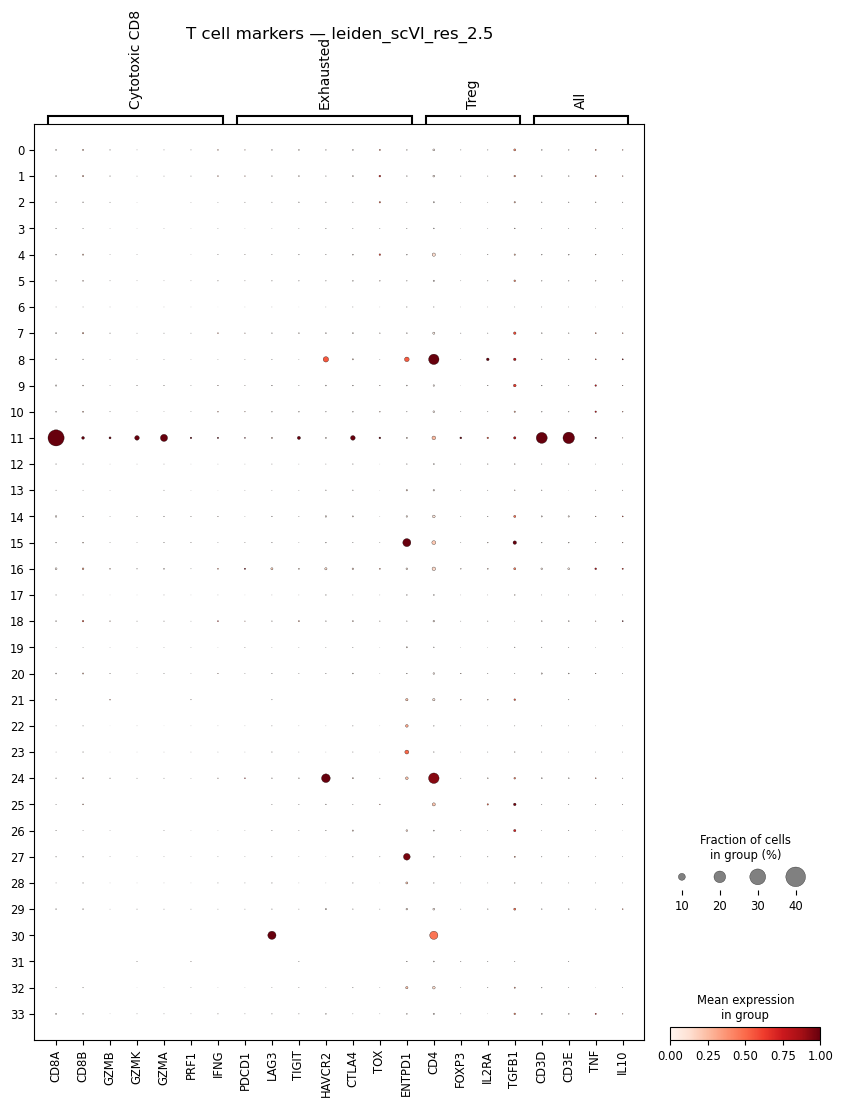


RESOLUTION: leiden_scVI_res_2


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['LAPTM4B', 'UCHL1', 'HNRNPD', 'CD47', 'H19', 'HSPD1', 'SMC4', 'HMGA1', 'PRKCI', 'AHCY', 'PTGES3', 'EPCAM', 'YWHAZ', 'EIF4G1', 'BIRC5']
Cluster 1: ['H19', 'PLXNB1', 'CD47', 'LAPTM4B', 'CP', 'MUC16', 'LCN2', 'NORAD', 'PRKCI', 'ESR1', 'CYP4B1', 'UCHL1', 'HNRNPD', 'BCAM', 'AHCY']
Cluster 2: ['EEF1G', 'PLXNB1', 'IMPDH2', 'NORAD', 'TMEM123', 'AHCY', 'FBL', 'CD47', 'APP', 'CP', 'PVT1', 'SNHG15', 'LAPTM4B', 'PRKCI', 'MUC16']
Cluster 3: ['HSPD1', 'SMC4', 'HSPE1', 'PRKCI', 'BIRC5', 'HNRNPD', 'KPNA2', 'TOP2A', 'CCNB1', 'PTGES3', 'CSE1L', 'CTNNB1', 'CD47', 'CDC20', 'CBX5']
Cluster 4: ['H19', 'EEF1G', 'CD47', 'LAPTM4B', 'YWHAZ', 'HSPD1', 'HNRNPD', 'FBL', 'PRKCI', 'HNRNPA1L2', 'NORAD', 'AHCY', 'PKM', 'IMPDH2', 'UCHL1']
Cluster 5: ['FOXJ1', 'CFAP100', 'MLF1', 'C20orf85', 'AC007906.2', 'IFT57', 'PLXNB1', 'RBM38', 'FAM183A', 'PTGES3', 'CYP4B1', 'HMGN3', 'UCHL1', 'TEKT1', 'F11R']
Cluster 6: ['C1QC', 'MS4A6A', 'AIF1', 'FCGR2A', 'CD14', 'ITGB2', 'ST

/tmp/ipykernel_2492726/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2492726/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2                                                         
0                            -0.017483            -0.034208   -0.042659   
1                            -0.014290            -0.027063   -0.025458   
2                            -0.013205            -0.021711   -0.024515   
3                            -0.015168            -0.032422   -0.042866   
4                            -0.005178            -0.011377   -0.013679   
5                            -0.050646            -0.048341   -0.052881   
6                            -0.009672             0.017794    0.103246   
7                            -0.012340            -0.024096   -0.026637   
8                            -0.010680            -0.015324   -0.002315   
9                             0.435901             0.328028    0.262825   
10                           -0.00

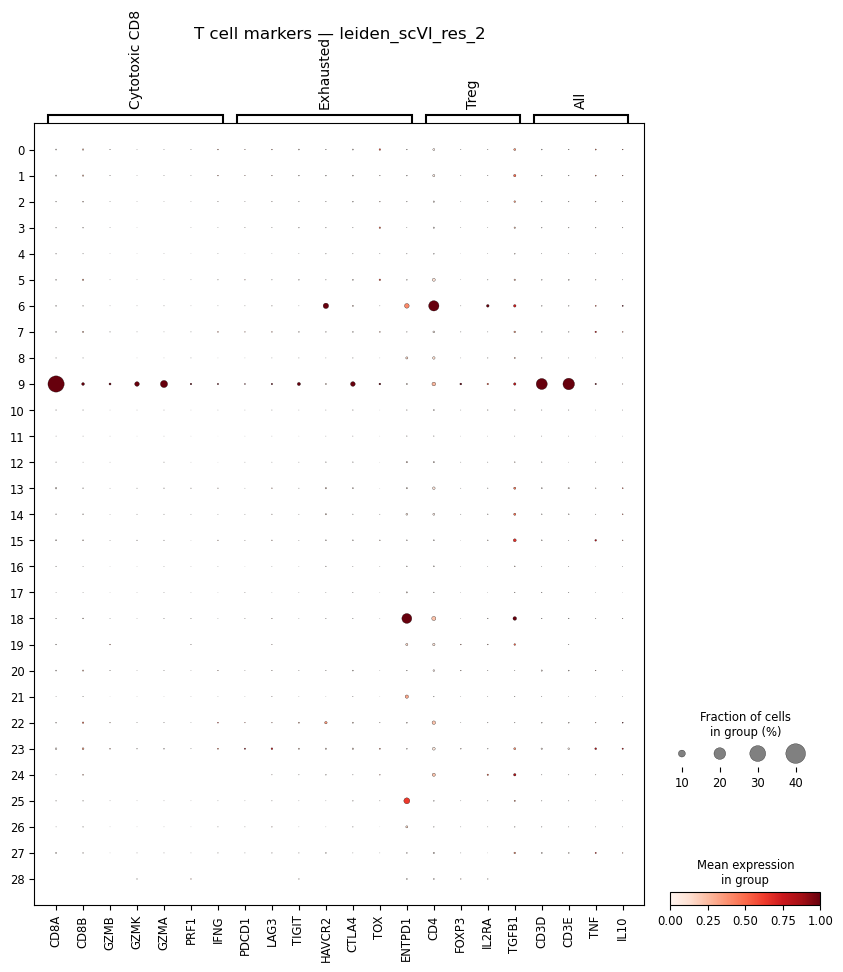


RESOLUTION: leiden_scVI_res_1.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['LAPTM4B', 'UCHL1', 'HNRNPD', 'CD47', 'H19', 'HSPD1', 'PRKCI', 'HMGA1', 'AHCY', 'PLXNB1', 'SMC4', 'ESR1', 'PTGES3', 'EPCAM', 'YWHAZ']
Cluster 1: ['H19', 'NDRG1', 'YWHAZ', 'CD47', 'LCN2', 'LAPTM4B', 'VEGFA', 'EEF1G', 'AMOTL2', 'LDHA', 'TFPI2', 'PRKCI', 'CP', 'APP', 'HSPD1']
Cluster 2: ['H19', 'EEF1G', 'CD47', 'LAPTM4B', 'YWHAZ', 'HSPD1', 'PRKCI', 'HNRNPD', 'FBL', 'PKM', 'UCHL1', 'CP', 'AHCY', 'HNRNPA1L2', 'NORAD']
Cluster 3: ['FOXJ1', 'C20orf85', 'CFAP100', 'AC007906.2', 'FAM183A', 'MLF1', 'IFT57', 'RBM38', 'TPPP3', 'TEKT1', 'CDHR4', 'PTGES3', 'PLXNB1', 'HMGN3', 'ERICH3']
Cluster 4: ['EEF1G', 'PLXNB1', 'IMPDH2', 'NORAD', 'CD47', 'PVT1', 'CP', 'AHCY', 'SNHG15', 'TMEM123', 'APP', 'FBL', 'LAPTM4B', 'PRKCI', 'MUC16']
Cluster 5: ['C1QC', 'MS4A6A', 'AIF1', 'FCGR2A', 'CD14', 'ITGB2', 'STAB1', 'FCGBP', 'MSR1', 'SGK1', 'SLCO2B1', 'C5AR1', 'CYBB', 'LIPA', 'CD163']
Cluster 6: ['HSPD1', 'SMC4', 'HSPE1', 'PRKCI', 'BIRC5', 'KPNA2', 'TOP2A', 'HN

/tmp/ipykernel_2492726/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2492726/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1.5                                                         
0                              -0.017236            -0.033468   -0.041213   
1                              -0.013770            -0.026255   -0.026815   
2                              -0.007463            -0.015855   -0.018271   
3                              -0.065896            -0.058932   -0.061247   
4                              -0.012917            -0.021794   -0.024118   
5                              -0.009896             0.018291    0.100629   
6                              -0.014828            -0.032186   -0.043725   
7                              -0.009978            -0.014700   -0.001950   
8                               0.419940             0.316339    0.254006   
9                              -0.007697            -0.011793   -0.007234   
10        

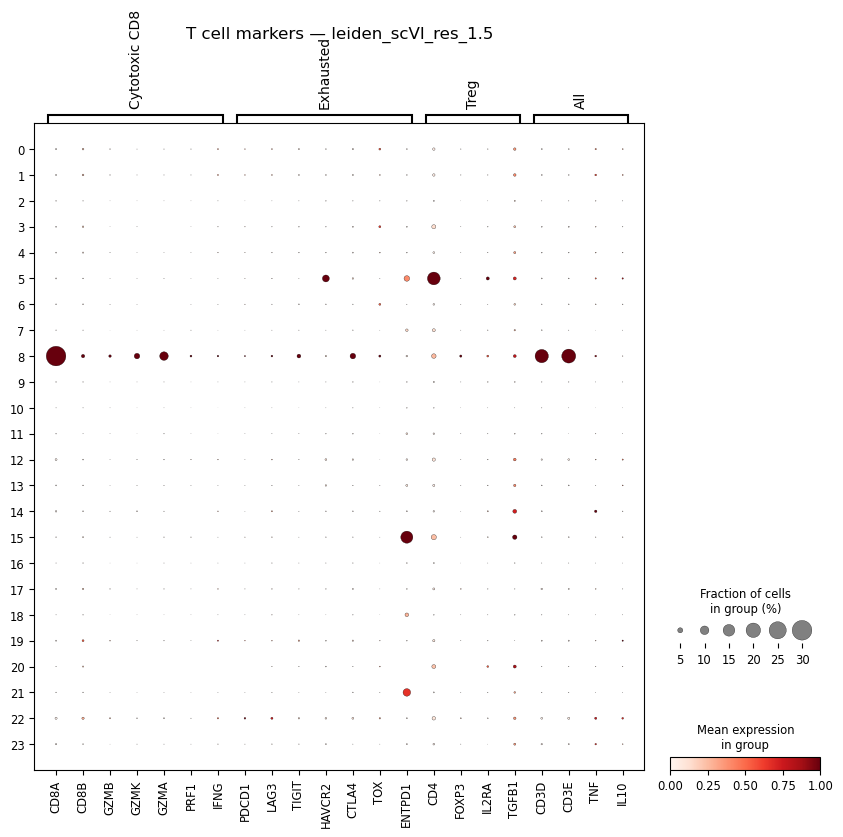


RESOLUTION: leiden_scVI_res_1

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['H19', 'LAPTM4B', 'CD47', 'HNRNPD', 'UCHL1', 'PRKCI', 'CP', 'YWHAZ', 'HSPD1', 'AHCY', 'PLXNB1', 'EEF1G', 'PKM', 'NORAD', 'EPCAM']
Cluster 1: ['EEF1G', 'PLXNB1', 'IMPDH2', 'NORAD', 'CD47', 'PVT1', 'SNHG15', 'AHCY', 'CP', 'LAPTM4B', 'FBL', 'PRKCI', 'TMEM123', 'APP', 'ESR1']
Cluster 2: ['EEF1G', 'AC007906.2', 'H3F3B', 'SNHG15', 'EIF3C', 'PLXNB1', 'KCNC3', 'FOXJ1', 'ESR1', 'HNRNPA1L2', 'LENG8', 'CLDN1', 'C20orf85', 'BCAM', 'IMPDH2']
Cluster 3: ['C1QC', 'MS4A6A', 'AIF1', 'FCGR2A', 'CD14', 'ITGB2', 'STAB1', 'FCGBP', 'MSR1', 'SGK1', 'SLCO2B1', 'C5AR1', 'CYBB', 'LIPA', 'MNDA']
Cluster 4: ['SMC4', 'HSPD1', 'HSPE1', 'PRKCI', 'BIRC5', 'KPNA2', 'HNRNPD', 'TOP2A', 'CCNB1', 'PTGES3', 'CDC20', 'CTNNB1', 'CBX5', 'CSE1L', 'CCT7']
Cluster 5: ['TRAC', 'CD52', 'CD8A', 'CXCR4', 'TRBC1', 'IL7R', 'CD3E', 'CD3D', 'CD2', 'IKZF1', 'CD96', 'GZMA', 'TBC1D10C', 'GZMH', 'IL2RG']
Cluster 6: ['C7', 'DCN', 'ABCA10', 'CCN1', 'ABCA8'

/tmp/ipykernel_2492726/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2492726/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1                                                         
0                            -0.015295            -0.029832   -0.034582   
1                            -0.013022            -0.021850   -0.024323   
2                            -0.026566            -0.033487   -0.035807   
3                            -0.009479             0.018109    0.098625   
4                            -0.014680            -0.032586   -0.043722   
5                             0.422441             0.317874    0.255005   
6                            -0.007644            -0.011843   -0.007441   
7                            -0.002241            -0.003509   -0.001347   
8                             0.001440             0.002394    0.004123   
9                            -0.016864            -0.025080   -0.026060   
10                           -0.01

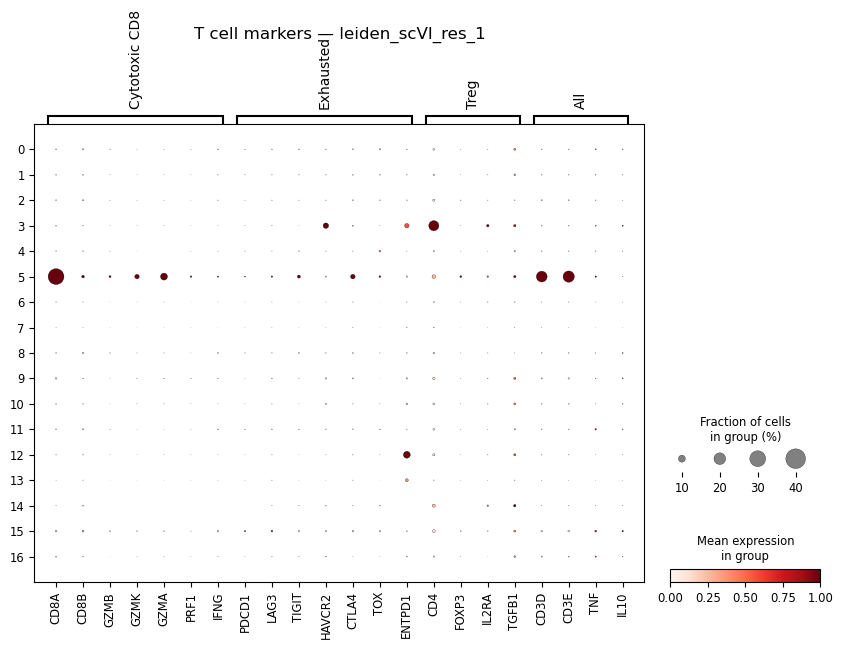


RESOLUTION: leiden_scVI_res_0.75

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['H19', 'CD47', 'LAPTM4B', 'HNRNPD', 'PRKCI', 'UCHL1', 'CP', 'YWHAZ', 'HSPD1', 'PLXNB1', 'AHCY', 'EEF1G', 'NORAD', 'ESR1', 'PKM']
Cluster 1: ['EEF1G', 'AC007906.2', 'H3F3B', 'SNHG15', 'EIF3C', 'PLXNB1', 'KCNC3', 'FOXJ1', 'ESR1', 'HNRNPA1L2', 'LENG8', 'CLDN1', 'C20orf85', 'BCAM', 'IMPDH2']
Cluster 2: ['EEF1G', 'PLXNB1', 'IMPDH2', 'NORAD', 'CD47', 'AHCY', 'PVT1', 'SNHG15', 'TMEM123', 'CP', 'FBL', 'APP', 'LAPTM4B', 'PRKCI', 'MUC16']
Cluster 3: ['C1QC', 'MS4A6A', 'AIF1', 'FCGR2A', 'CD14', 'ITGB2', 'STAB1', 'FCGBP', 'MSR1', 'NAMPT', 'SGK1', 'C5AR1', 'MNDA', 'SLCO2B1', 'CYBB']
Cluster 4: ['SMC4', 'HSPD1', 'HSPE1', 'PRKCI', 'BIRC5', 'KPNA2', 'TOP2A', 'HNRNPD', 'CCNB1', 'PTGES3', 'CDC20', 'CTNNB1', 'CBX5', 'CSE1L', 'CCT7']
Cluster 5: ['TRAC', 'CD52', 'CD8A', 'CXCR4', 'TRBC1', 'IL7R', 'CD3E', 'CD3D', 'CD2', 'IKZF1', 'CD96', 'GZMA', 'TBC1D10C', 'GZMH', 'CD44']
Cluster 6: ['C7', 'DCN', 'ABCA10', 'CCN1', 'ABC

/tmp/ipykernel_2492726/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2492726/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.75                                                         
0                               -0.014979            -0.029176   -0.033556   
1                               -0.026655            -0.033716   -0.036061   
2                               -0.013052            -0.021542   -0.024081   
3                               -0.008953             0.016665    0.091472   
4                               -0.015064            -0.032837   -0.044853   
5                                0.405300             0.305069    0.245996   
6                               -0.006736            -0.010585   -0.006824   
7                                0.001282             0.001371    0.002180   
8                               -0.016518            -0.025349   -0.026982   
9                               -0.011752            -0.016203   -0.010944  

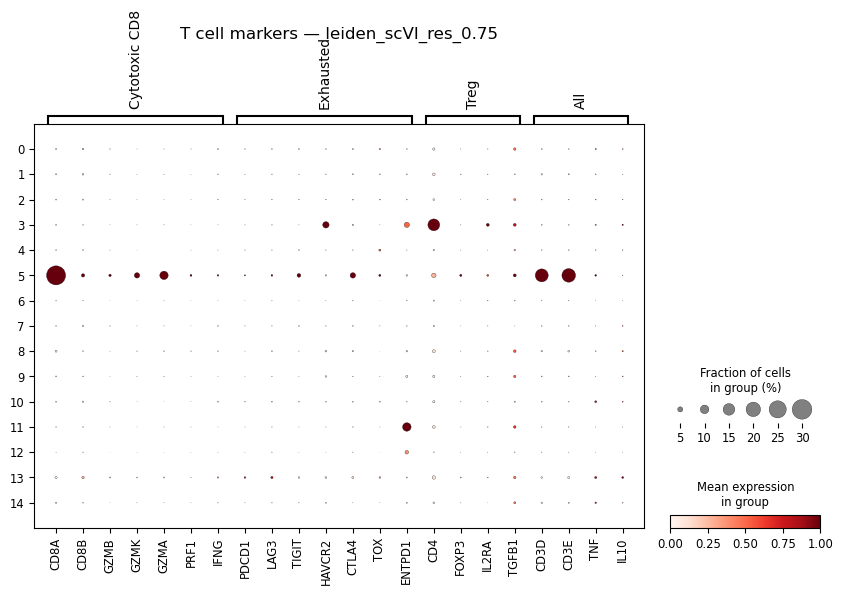


RESOLUTION: leiden_scVI_res_0.65

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['H19', 'CD47', 'LAPTM4B', 'YWHAZ', 'PRKCI', 'HSPD1', 'EEF1G', 'HNRNPD', 'CP', 'AHCY', 'UCHL1', 'PLXNB1', 'PKM', 'EIF4G1', 'EPCAM']
Cluster 1: ['EEF1G', 'AC007906.2', 'H3F3B', 'SNHG15', 'EIF3C', 'PLXNB1', 'KCNC3', 'FOXJ1', 'ESR1', 'LENG8', 'HNRNPA1L2', 'CLDN1', 'C20orf85', 'BCAM', 'IMPDH2']
Cluster 2: ['EEF1G', 'PLXNB1', 'IMPDH2', 'NORAD', 'CD47', 'TMEM123', 'AHCY', 'APP', 'FBL', 'CP', 'SNHG15', 'PVT1', 'LAPTM4B', 'PRKCI', 'MUC16']
Cluster 3: ['C1QC', 'MS4A6A', 'AIF1', 'FCGR2A', 'CD14', 'ITGB2', 'STAB1', 'FCGBP', 'NAMPT', 'MSR1', 'SGK1', 'C5AR1', 'MNDA', 'SLCO2B1', 'CYBB']
Cluster 4: ['SMC4', 'HSPD1', 'HSPE1', 'PRKCI', 'BIRC5', 'KPNA2', 'TOP2A', 'HNRNPD', 'CCNB1', 'PTGES3', 'CDC20', 'CTNNB1', 'CBX5', 'CSE1L', 'CCT7']
Cluster 5: ['TRAC', 'CD52', 'CD8A', 'CXCR4', 'TRBC1', 'IL7R', 'CD3E', 'CD3D', 'CD2', 'IKZF1', 'CD96', 'GZMA', 'TBC1D10C', 'GZMH', 'CD44']
Cluster 6: ['C7', 'DCN', 'ABCA10', 'CCN1', 'A

/tmp/ipykernel_2492726/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2492726/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.65                                                         
0                               -0.014274            -0.027892   -0.031970   
1                               -0.026788            -0.033741   -0.036087   
2                               -0.013039            -0.021369   -0.024171   
3                               -0.008859             0.016774    0.091488   
4                               -0.015241            -0.033033   -0.045189   
5                                0.405750             0.305468    0.246438   
6                               -0.006714            -0.010587   -0.006778   
7                                0.001094             0.001298    0.002225   
8                               -0.016613            -0.025674   -0.027325   
9                               -0.011720            -0.016175   -0.010950  

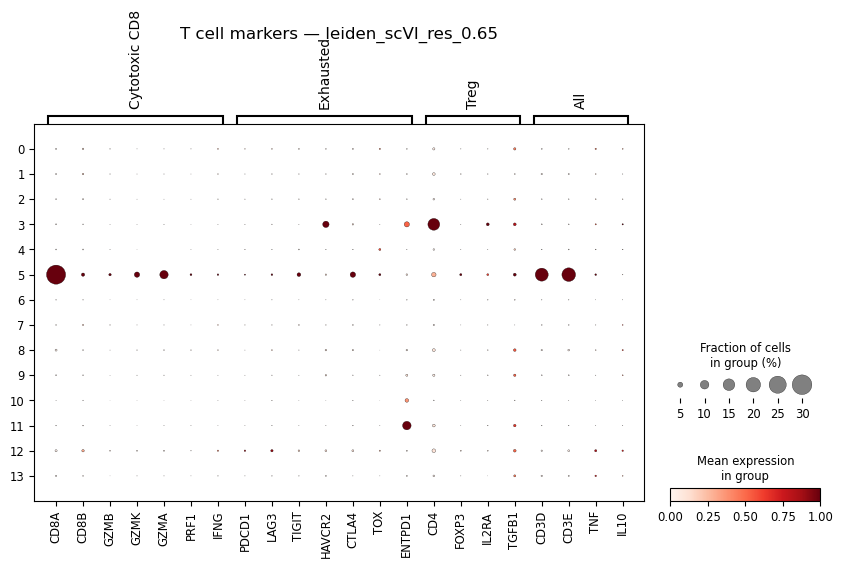


RESOLUTION: leiden_scVI_res_0.5

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['H19', 'CD47', 'LAPTM4B', 'YWHAZ', 'PRKCI', 'HSPD1', 'EEF1G', 'HNRNPD', 'CP', 'AHCY', 'UCHL1', 'PLXNB1', 'PKM', 'ESR1', 'EPCAM']
Cluster 1: ['EEF1G', 'AC007906.2', 'H3F3B', 'SNHG15', 'EIF3C', 'PLXNB1', 'KCNC3', 'FOXJ1', 'ESR1', 'LENG8', 'HNRNPA1L2', 'CLDN1', 'C20orf85', 'BCAM', 'IMPDH2']
Cluster 2: ['EEF1G', 'PLXNB1', 'IMPDH2', 'NORAD', 'TMEM123', 'AHCY', 'APP', 'FBL', 'CD47', 'CP', 'SNHG15', 'PVT1', 'LAPTM4B', 'MUC16', 'PRKCI']
Cluster 3: ['C1QC', 'MS4A6A', 'AIF1', 'FCGR2A', 'CD14', 'ITGB2', 'STAB1', 'FCGBP', 'MSR1', 'NAMPT', 'SGK1', 'C5AR1', 'MNDA', 'SLCO2B1', 'CYBB']
Cluster 4: ['SMC4', 'HSPD1', 'HSPE1', 'PRKCI', 'BIRC5', 'KPNA2', 'TOP2A', 'CCNB1', 'HNRNPD', 'PTGES3', 'CDC20', 'CTNNB1', 'CBX5', 'CSE1L', 'CCT7']
Cluster 5: ['TRAC', 'CD52', 'CD8A', 'CXCR4', 'TRBC1', 'IL7R', 'CD3E', 'CD3D', 'CD2', 'IKZF1', 'CD96', 'GZMA', 'TBC1D10C', 'GZMH', 'CD44']
Cluster 6: ['C7', 'DCN', 'ABCA10', 'CCN1', 'ABCA

/tmp/ipykernel_2492726/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2492726/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.5                                                         
0                              -0.014169            -0.027613   -0.031582   
1                              -0.026656            -0.033637   -0.036253   
2                              -0.012886            -0.021109   -0.023988   
3                              -0.008868             0.016814    0.091843   
4                              -0.015824            -0.033532   -0.045723   
5                               0.406975             0.306398    0.247389   
6                              -0.006686            -0.010612   -0.006779   
7                               0.001209             0.001498    0.002457   
8                              -0.017032            -0.025707   -0.027298   
9                              -0.011565            -0.015970   -0.010731   
10        

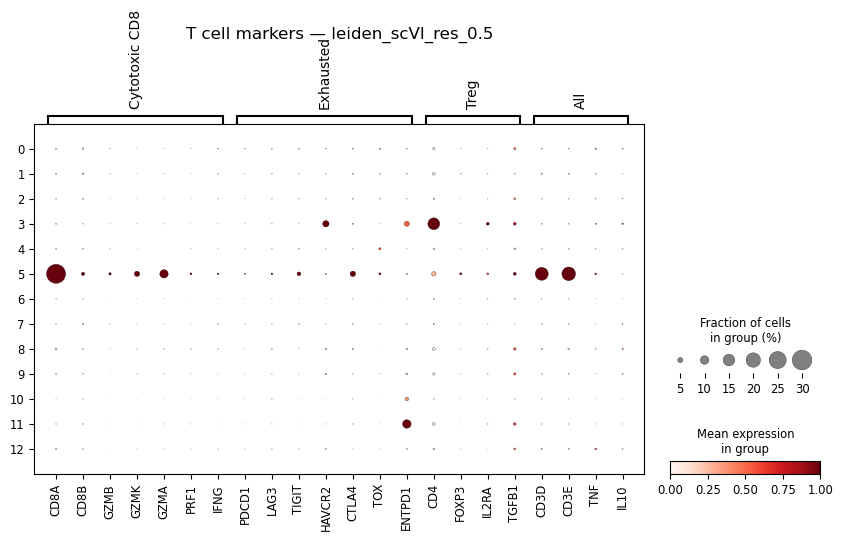

In [8]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

marker_genes_dotplot = {
    'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
    'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    'All': ['CD3D', 'CD3E', 'TNF', 'IL10'],
}


def annotate_clusters(adata, groupby_key, n_top_genes=15, de_genes_dict=None):
    print(f"\n{'='*60}")
    print(f"RESOLUTION: {groupby_key}")
    print(f"{'='*60}")
    
    # --- Approach 1: top DE genes per cluster (on log_norm) ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby_key,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    
    # Initialize dictionary for this resolution if provided
    if de_genes_dict is not None:
        de_genes_dict[groupby_key] = {}
    
    print("\n--- Top DE genes per cluster (log_norm) ---")
    for group in groups:
        top_genes = result['names'][group][:n_top_genes]
        print(f"Cluster {group}: {list(top_genes)}")
        # Save DE genes to the dictionary
        if de_genes_dict is not None:
            de_genes_dict[groupby_key][group] = list(top_genes)
    
    # --- Approach 2: marker set scores per cluster (on log_norm) ---
    for name, genes in marker_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f'{name}_score',
            layer='log_norm'
        )
    
    score_cols = [f'{name}_score' for name in marker_sets.keys()]

    # 1. Calculate the mean scores per cluster
    cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
    # 2. Calculate the cell count per cluster and add it as a new column
    cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()
    print("\n--- Marker set scores and cell counts per cluster (log_norm) ---")
    print(cluster_scores)
    
    # --- Approach 3: dot plot (on log_norm) ---
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )
    
    return cluster_scores

# Initialize the dictionary and run the loop
de_genes_dict = {}
all_scores = {}
for res_key in res_labels:
    all_scores[res_key] = annotate_clusters(adata, res_key, de_genes_dict=de_genes_dict)

In [9]:
all_scores[res_label(0.75)]

,Cytotoxic_CD8_score,Exhausted_CD8_score,Treg_score,cell_count
leiden_scVI_res_0.75,,,,
0,-0.014979,-0.029176,-0.033556,105971
1,-0.026655,-0.033716,-0.036061,5150
2,-0.013052,-0.021542,-0.024081,47917
3,-0.008953,0.016665,0.091472,36850
4,-0.015064,-0.032837,-0.044853,1914
5,0.405300,0.305069,0.245996,9325
6,-0.006736,-0.010585,-0.006824,30723
7,0.001282,0.001371,0.002180,17978
8,-0.016518,-0.025349,-0.026982,2547


/tmp/ipykernel_2492726/1014824437.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');


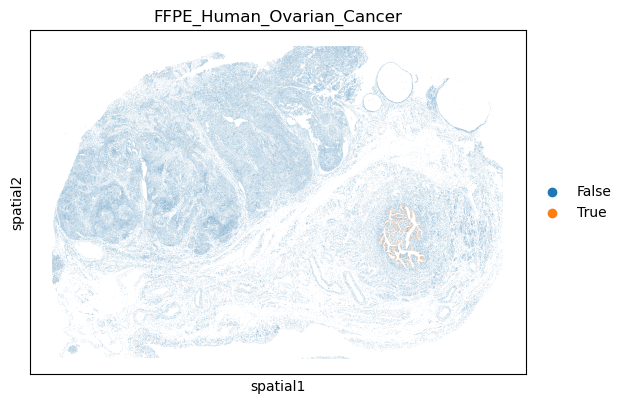

In [10]:
# NOTE: cd8/cd4 top-level clusters per collaborator's corrected numbers.
# Assumed identified at res_0.75 (res below) -- verify the resolution matches.
res = 0.75
cd8 = ['5'] #CD8
cd4 = ['3'] #CD4
t_cell_clusts = list(set(cd8 + cd4))
adata.obs['cd8'] = adata.obs[res_label(res)].isin(cd8)
adata.obs['cd4'] = adata.obs[res_label(res)].isin(cd4)
adata.obs['t_cell'] = adata.obs[res_label(res)].isin(t_cell_clusts)
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');


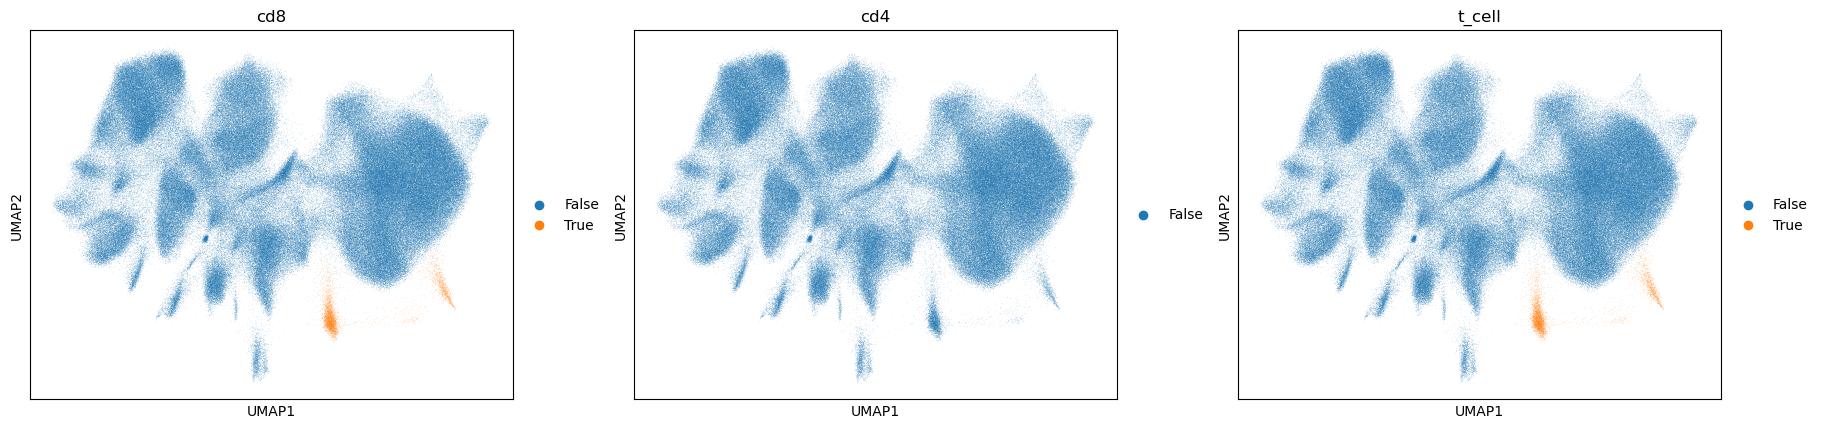

In [11]:
sc.pl.umap(adata, color=['cd8', 'cd4', 't_cell'])

In [12]:
print(f'Not t cell: {sum(~adata.obs['t_cell'])}')
print(f't cell: {sum(adata.obs['t_cell'])}')
print(f'cd8: {sum(adata.obs['cd8'])}')
print(f'cd4: {sum(adata.obs['cd4'])}')

Not t cell: 401974
t cell: 5150
cd8: 5150
cd4: 0


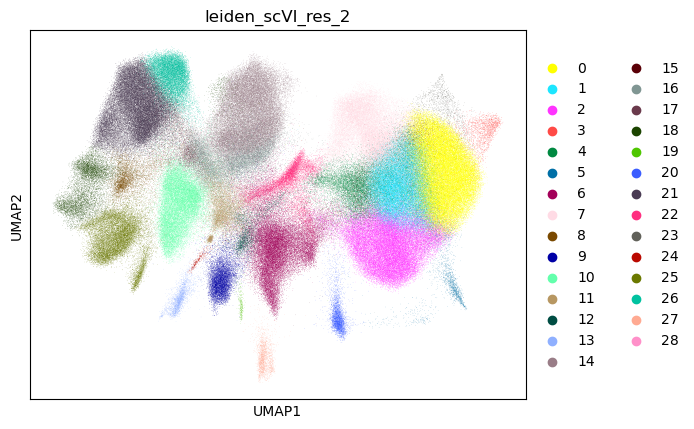

In [13]:
sc.pl.umap(adata, color=[res_label(2)])

In [ ]:
def sub_res_label(res, clusters):
    """Order of clusters does not matter"""
    return f'sub_cluster_{"-".join(sorted(clusters))}_res_{res}'

def subcluster(adata, clusters, sub_res, clusters_res_label, de_genes_dict=None):
    print(f'Starting Sub Resolutions {sub_res}')
    new_col_name = sub_res_label(sub_res, clusters)

    # 2. Filter the adata to include only the targeted clusters
    subset_mask = adata.obs[clusters_res_label].isin(clusters)
    adata_sub = adata[subset_mask].copy()

    if new_col_name in adata.obs:
        print(f'{new_col_name} already in adata, skipping')
        # Re-load the existing labels into the subset for DE calculation
        adata_sub.obs[new_col_name] = adata.obs.loc[subset_mask, new_col_name].values
    else:
        # 3. Run the Leiden clustering on the subset
        sc.tl.leiden(adata_sub, resolution=sub_res, key_added=new_col_name, flavor='igraph')
        
        # 4. Initialize the new column in the original adata with "other"
        adata.obs[new_col_name] = "other"
        
        # 5. Map the subset's new cluster results back to the original adata
        adata.obs.loc[subset_mask, new_col_name] = adata_sub.obs[new_col_name].astype(str)
        adata.obs[new_col_name] = adata.obs[new_col_name].astype('category')
    
    # Dot plot base setup
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    
    # Compute top DE genes for each new subcluster
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby=new_col_name,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata_sub.uns['rank_genes_groups']
    sub_groups = result['names'].dtype.names
    
    # Add top 10 DE genes per subcluster to the dotplot
    for group in sub_groups:
        top_sub_genes = result['names'][group][:10]
        marker_genes_filt[f'Subcluster {group} Top DE'] = [g for g in top_sub_genes if g in adata.var_names]

    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=new_col_name,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers & Subcluster DE — {new_col_name}'
    )

    print(f"\nSub-cluster sizes for {new_col_name}:")
    print(adata.obs[new_col_name].value_counts())
    
    return adata

In [15]:
sub_resolutions = [1, 0.75, 0.5, 0.37, 0.25, 0.15, 0.1, 0.05]

starting cd4
Starting Sub Resolutions 1


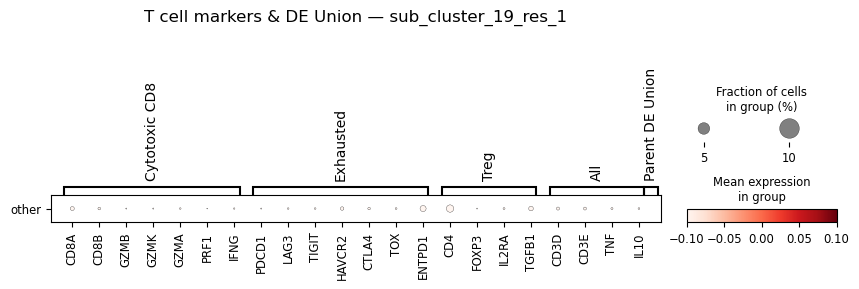


Sub-cluster sizes for sub_cluster_19_res_1:
sub_cluster_19_res_1
other    407124
Name: count, dtype: int64
Starting Sub Resolutions 0.75


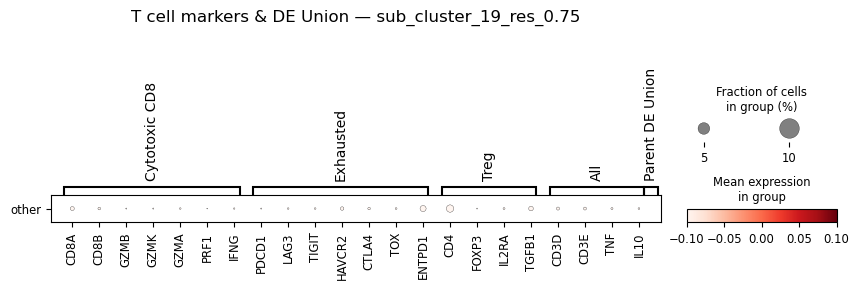


Sub-cluster sizes for sub_cluster_19_res_0.75:
sub_cluster_19_res_0.75
other    407124
Name: count, dtype: int64
Starting Sub Resolutions 0.5


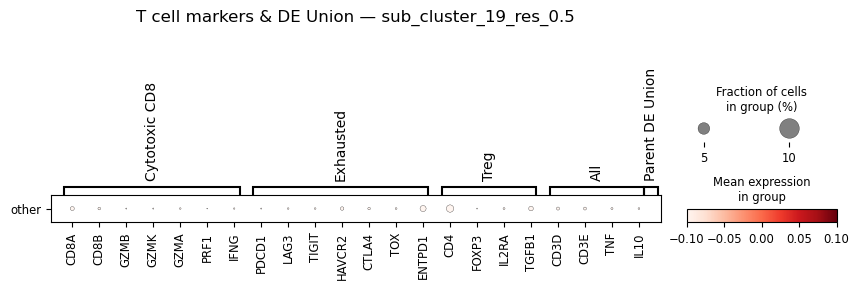


Sub-cluster sizes for sub_cluster_19_res_0.5:
sub_cluster_19_res_0.5
other    407124
Name: count, dtype: int64
Starting Sub Resolutions 0.37


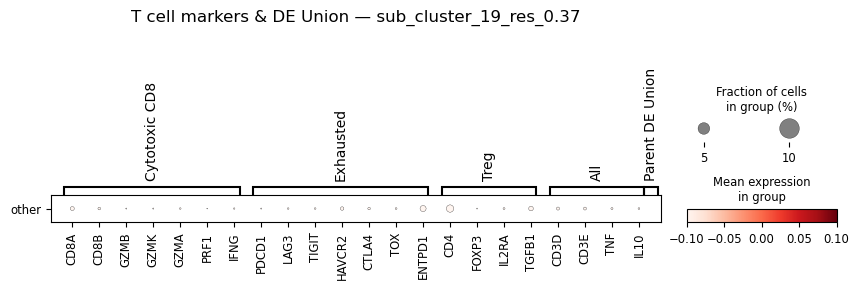


Sub-cluster sizes for sub_cluster_19_res_0.37:
sub_cluster_19_res_0.37
other    407124
Name: count, dtype: int64
Starting Sub Resolutions 0.25


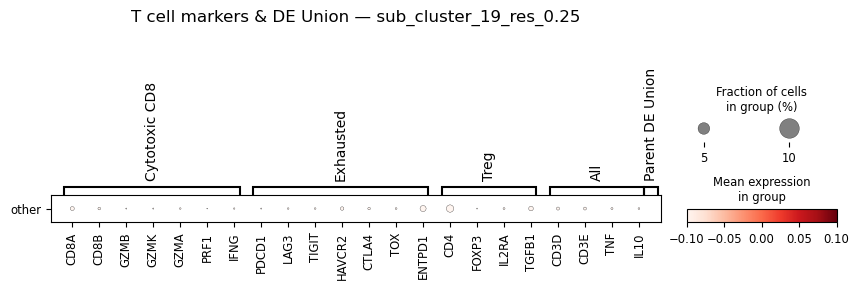


Sub-cluster sizes for sub_cluster_19_res_0.25:
sub_cluster_19_res_0.25
other    407124
Name: count, dtype: int64
Starting Sub Resolutions 0.15


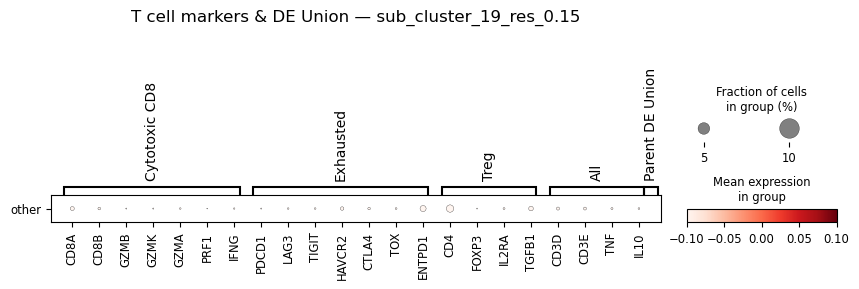


Sub-cluster sizes for sub_cluster_19_res_0.15:
sub_cluster_19_res_0.15
other    407124
Name: count, dtype: int64
Starting Sub Resolutions 0.1


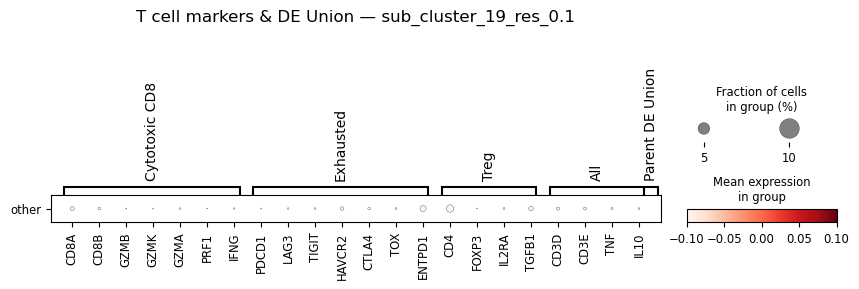


Sub-cluster sizes for sub_cluster_19_res_0.1:
sub_cluster_19_res_0.1
other    407124
Name: count, dtype: int64
Starting Sub Resolutions 0.05


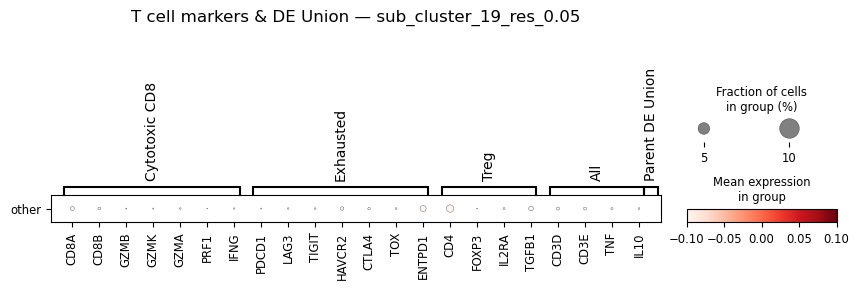


Sub-cluster sizes for sub_cluster_19_res_0.05:
sub_cluster_19_res_0.05
other    407124
Name: count, dtype: int64


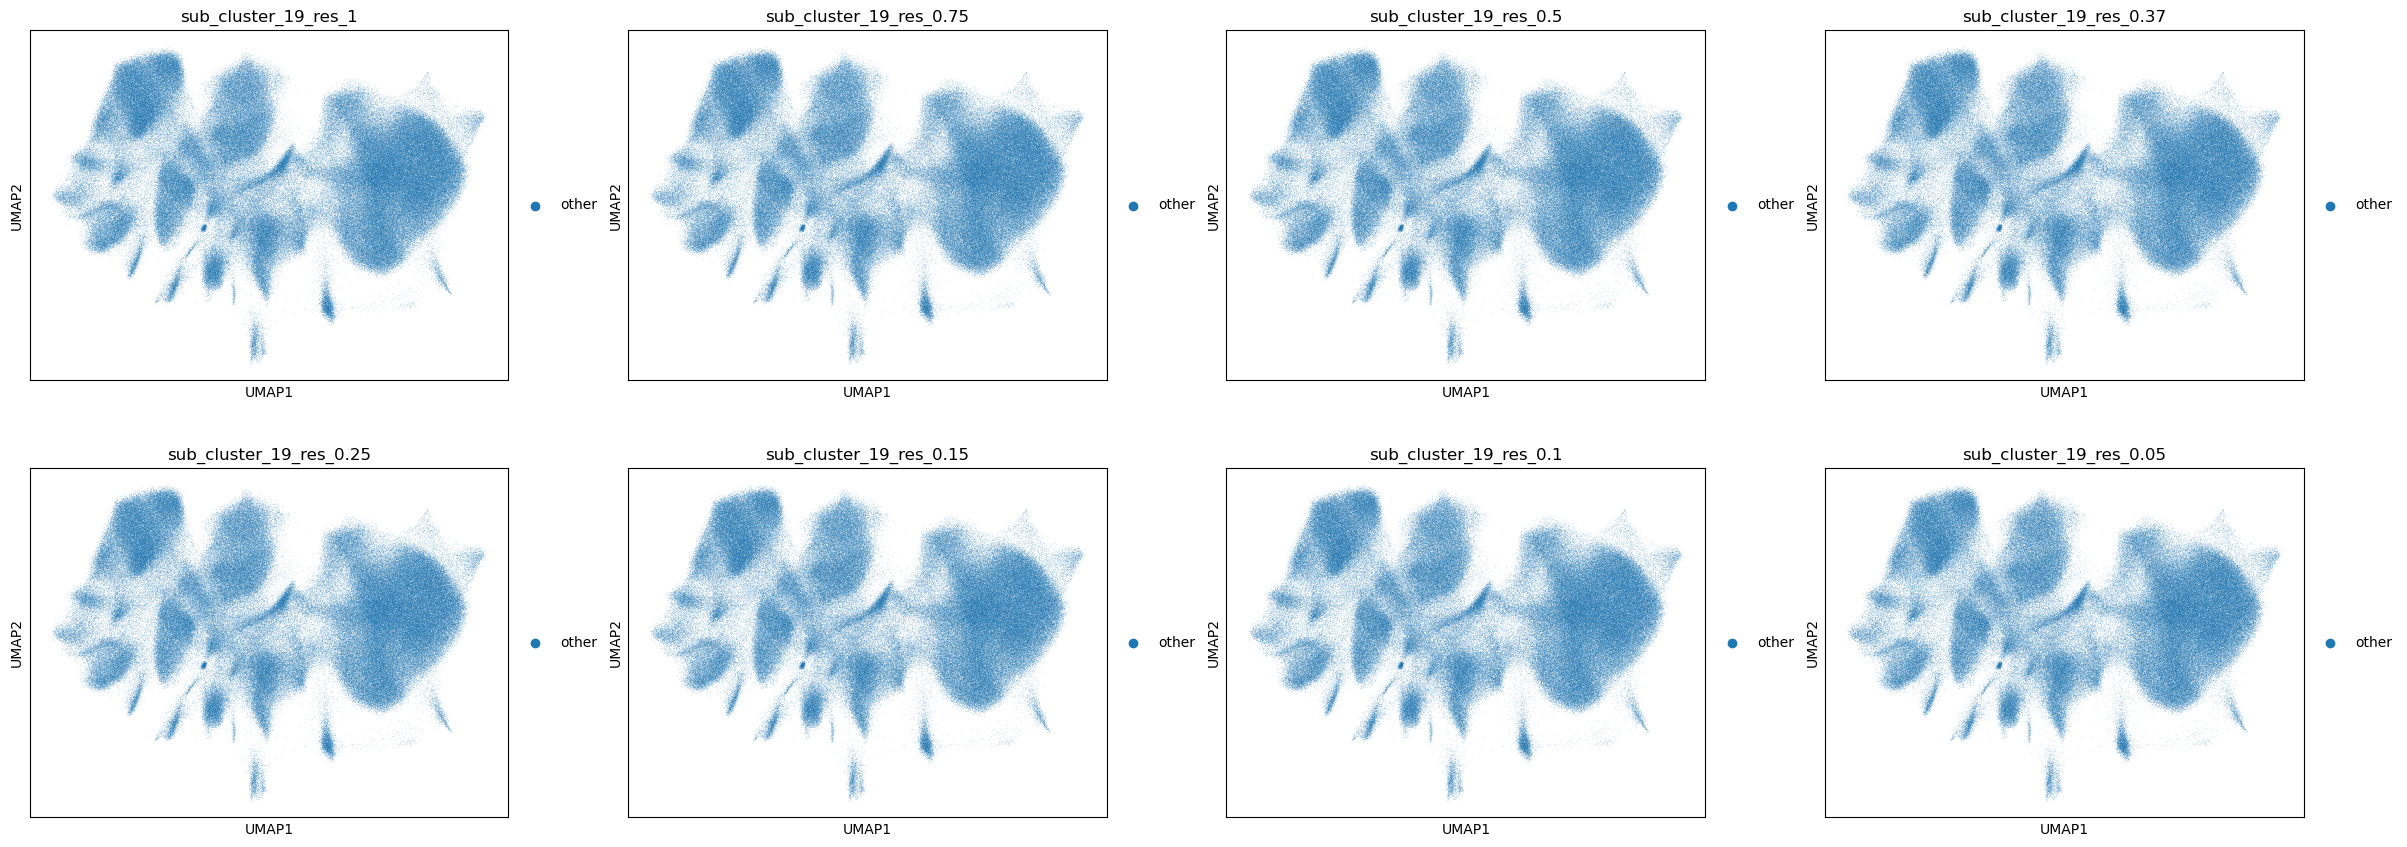

In [16]:
print('starting cd4')
for sub_res in sub_resolutions:
    subcluster(adata, cd4, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd4) for sub_res in sub_resolutions])

starting cd8
Starting Sub Resolutions 1


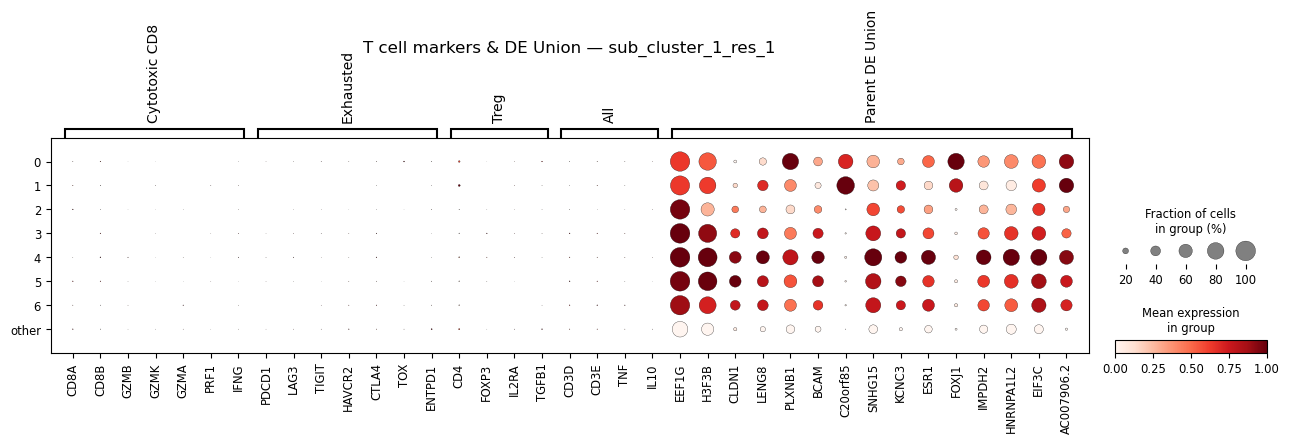


Sub-cluster sizes for sub_cluster_1_res_1:
sub_cluster_1_res_1
other    401974
0          1257
2           979
4           933
5           905
3           511
6           318
1           247
Name: count, dtype: int64
Starting Sub Resolutions 0.75


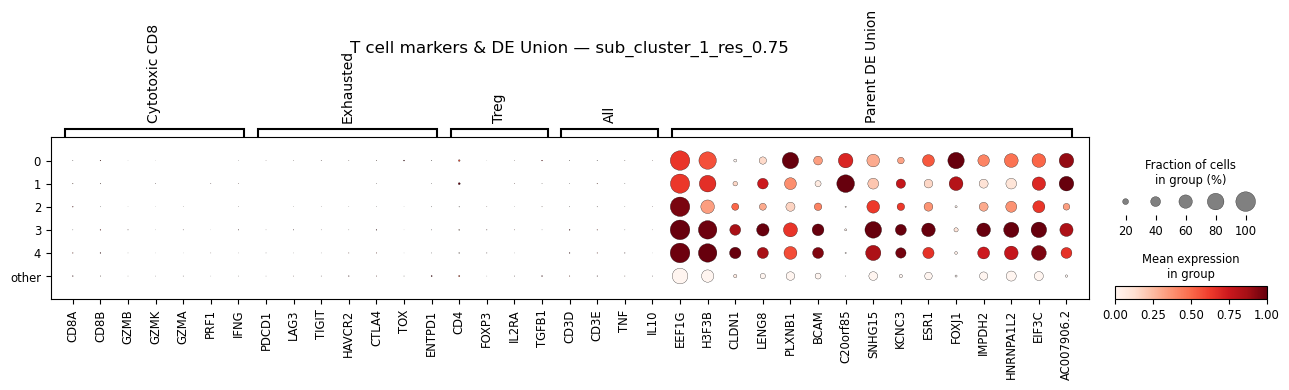


Sub-cluster sizes for sub_cluster_1_res_0.75:
sub_cluster_1_res_0.75
other    401974
3          1468
0          1259
4          1112
2          1068
1           243
Name: count, dtype: int64
Starting Sub Resolutions 0.5


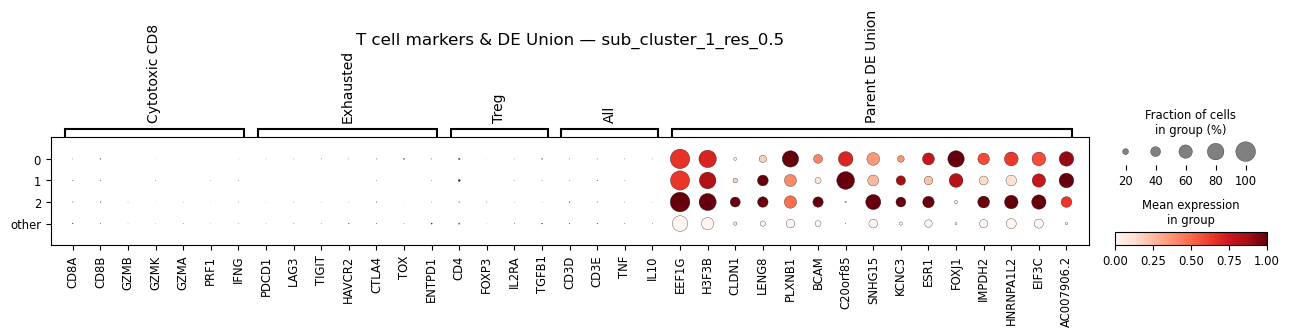


Sub-cluster sizes for sub_cluster_1_res_0.5:
sub_cluster_1_res_0.5
other    401974
2          3650
0          1259
1           241
Name: count, dtype: int64
Starting Sub Resolutions 0.37


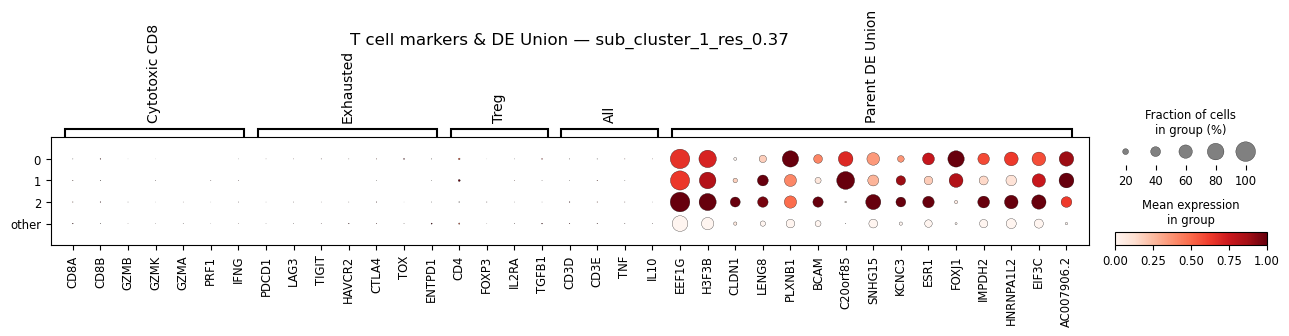


Sub-cluster sizes for sub_cluster_1_res_0.37:
sub_cluster_1_res_0.37
other    401974
2          3652
0          1261
1           237
Name: count, dtype: int64
Starting Sub Resolutions 0.25


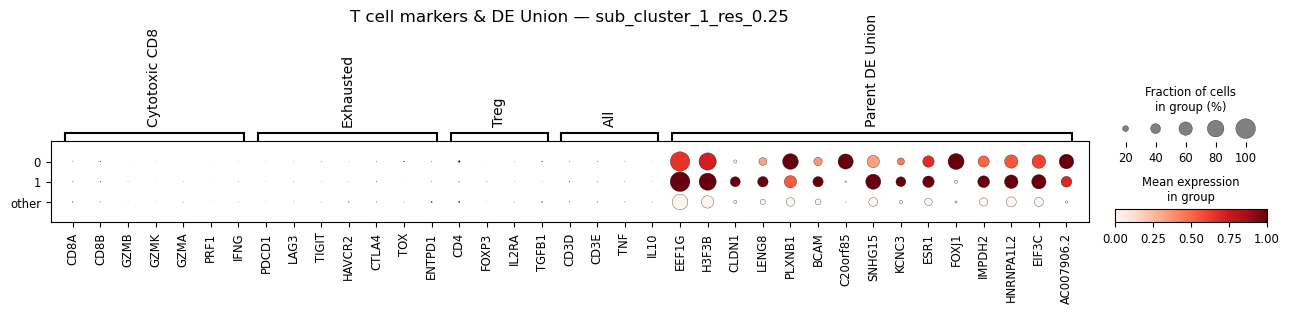


Sub-cluster sizes for sub_cluster_1_res_0.25:
sub_cluster_1_res_0.25
other    401974
1          3655
0          1495
Name: count, dtype: int64
Starting Sub Resolutions 0.15


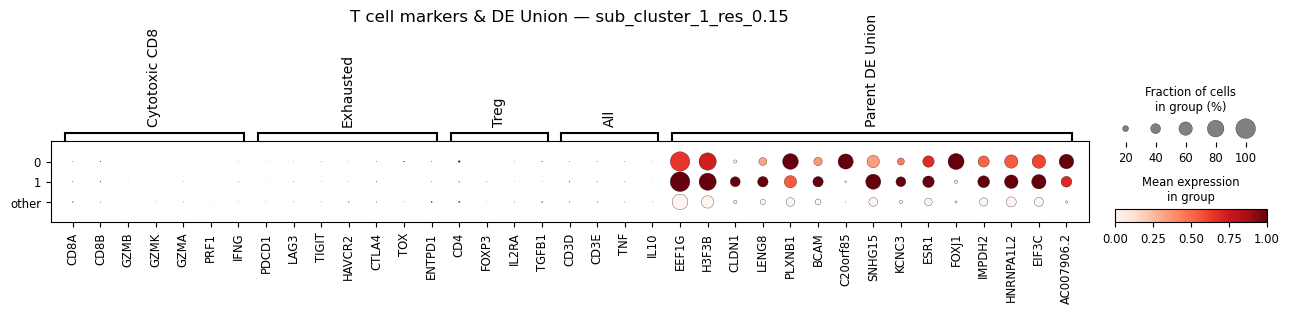


Sub-cluster sizes for sub_cluster_1_res_0.15:
sub_cluster_1_res_0.15
other    401974
1          3662
0          1488
Name: count, dtype: int64
Starting Sub Resolutions 0.1


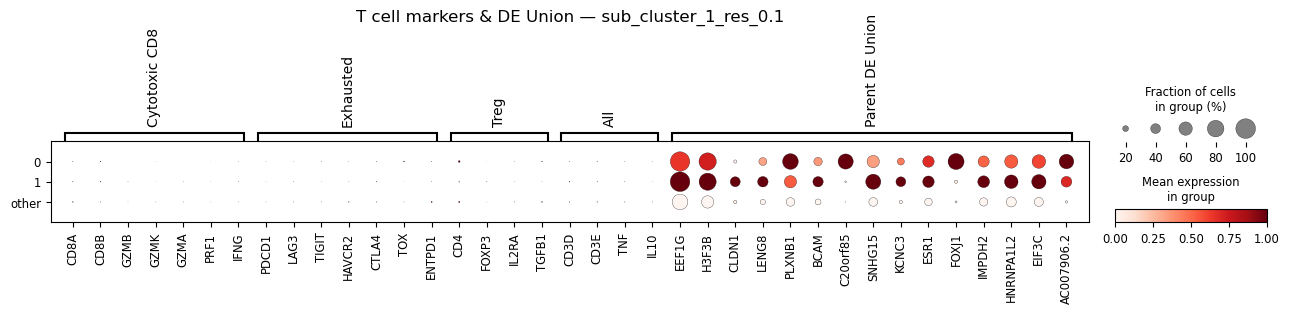


Sub-cluster sizes for sub_cluster_1_res_0.1:
sub_cluster_1_res_0.1
other    401974
1          3662
0          1488
Name: count, dtype: int64
Starting Sub Resolutions 0.05


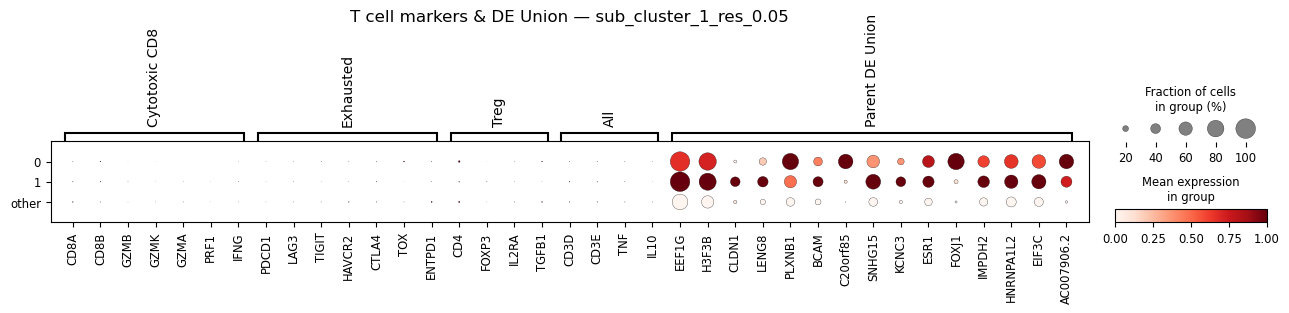


Sub-cluster sizes for sub_cluster_1_res_0.05:
sub_cluster_1_res_0.05
other    401974
1          3888
0          1262
Name: count, dtype: int64


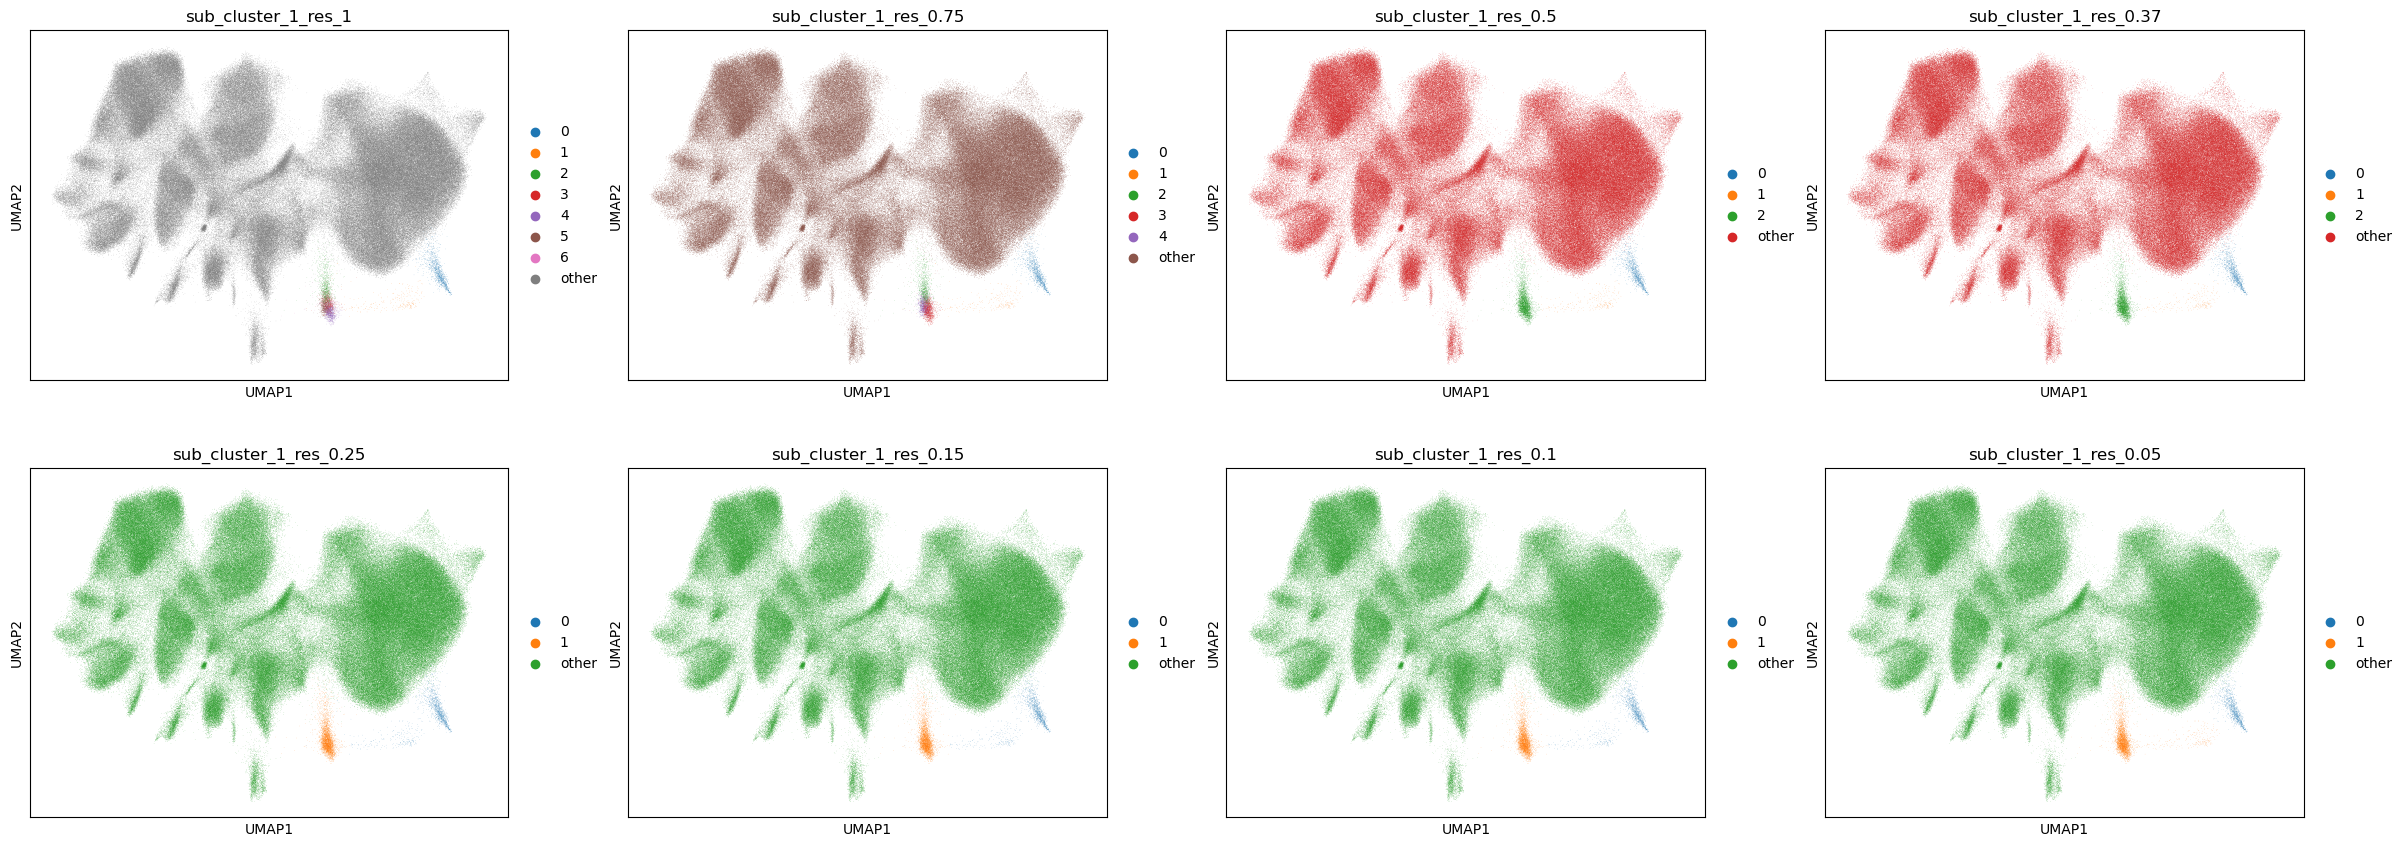

In [17]:
print('starting cd8')
for sub_res in sub_resolutions:
    subcluster(adata, cd8, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd8) for sub_res in sub_resolutions])

In [18]:
# Time to assign
# NOTE: fine (Tier3) T-cell labels are PENDING -- collaborator still needs to
# annotate the CD8/CD4 subclusters ("subcluster both"). For now only the
# coarse tiers are set; Tier3 stays 'other' until those annotations arrive.

# Tier1
adata.obs['Tier1'] = 'other'
adata.obs.loc[adata.obs['t_cell'], 'Tier1'] = 'T Cell'
adata.obs['Tier1'] = adata.obs['Tier1'].astype('category')

# Tier2
conditions = [
    adata.obs[res_label(res)].isin(cd8),
    adata.obs[res_label(res)].isin(cd4)
]
choices = ['CD8 T Cell', 'CD4 T Cell']
adata.obs['Tier2'] = np.select(conditions, choices, default='other')
adata.obs['Tier2'] = adata.obs['Tier2'].astype('category')

# Tier3  (pending subcluster annotations)
adata.obs['Tier3'] = 'other'


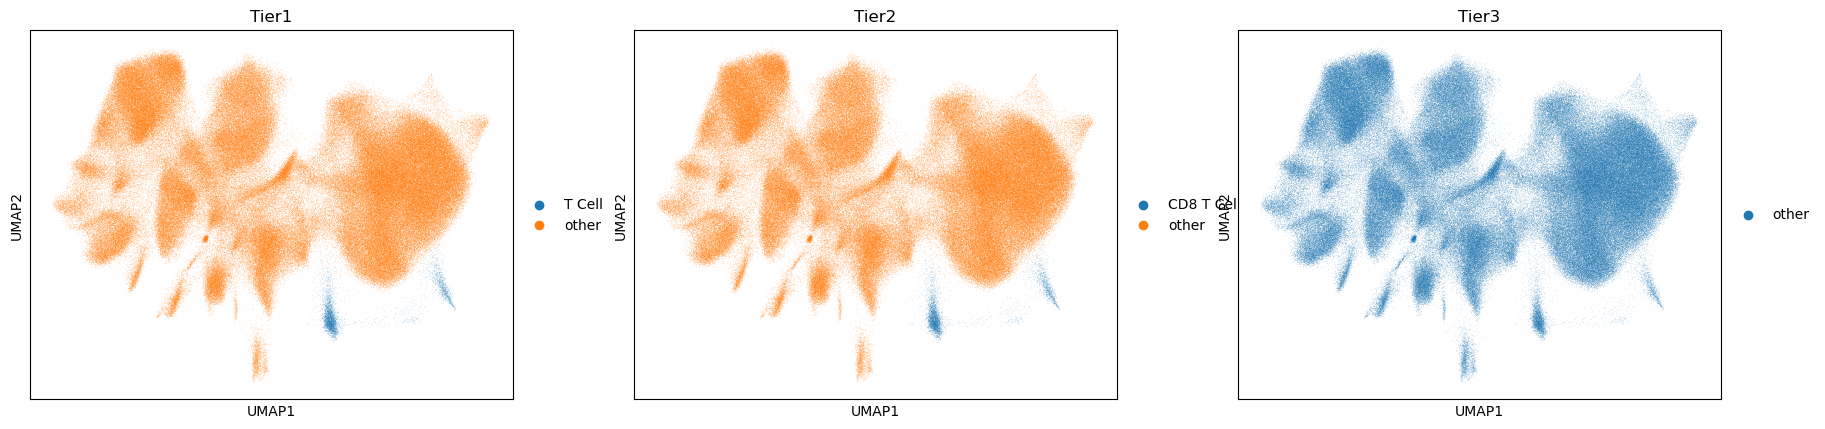

In [19]:
sc.pl.umap(adata, color=['Tier1', 'Tier2', 'Tier3'])

In [20]:
# adata.write_h5ad(f'{DATA_DIR}/adata.h5ad')